---
title: "The Davidson bubble: where 0.711's companions come from"
description: "A single bubble in an incipiently fluidised bed is a Laplace problem with a uniform-pressure hole in it. Solving it once, with pymrm, produces both the cloud that Kunii and Levenspiel's equation 9 gives and the 4.5 that opens their equation 10 - two consecutive equations that are stated, never derived, and turn out to be one flow field read twice."
categories: [sec:E, struct:S3, tier:T0, data:tier6, phase:gas-solid]
date: 2026-07-31
---

# The Davidson bubble: where 0.711's companions come from

**Catalog ID:** `E1.2` · **Structures:** `S3` (1D steady BVP) · **Tier:** T0

Every bubbling fluidised-bed reactor model starts from three numbers about *one*
bubble: how fast it rises, how much emulsion it drags round with it as a
**cloud**, and how much gas percolates straight **through** it. Two of the three
come out of a single idea: treat the emulsion as an inviscid incompressible fluid
and the interstitial gas as a Darcy flow through it, so that the bubble becomes a
sphere of *uniform pressure* embedded in a harmonic pressure field.

This page solves that flow problem numerically and recovers **two** of the three
— the cloud and the through-flow. The rise velocity is **taken as given**: the
`0.711` is the Davies–Taylor spherical-cap coefficient and does not follow from
the percolation problem at all. The point is not that a closed form exists — it
does, and the page uses it as the reference. The point is that the cloud volume
and the interchange coefficient, which appear in the reactor literature as two
unrelated correlations, are **one field evaluated twice**, and a numerical solve
makes that visible in a way the printed formulae do not.

**On sources, plainly.** Every equation and every number on this page was read
from **Kunii & Levenspiel (1968)**,
[doi:10.1021/i260028a001](https://doi.org/10.1021/i260028a001), which prints them
as its equations 3, 9, 10, 11 and 17 and — this is what makes the reprint carry
the case — *evaluates* each of them, with the arithmetic shown and the answer
printed, in three worked appendices.

Their attribution for the underlying object is thin, and the exact strength of it
is worth stating rather than paraphrasing. The name Davidson appears in the body
of the paper **once**: in a parenthesis on journal page 490, inside a list of the
model's simplifying assumptions — *"many simplifying assumptions were made in
developing this model (the Davidson bubble, bed with single size of bubbles,
emulsion at minimum fluidizing conditions at all gas velocities, etc.)"*. That is
the whole of it. There is **no** Davidson & Harrison entry in their literature
cited (journal page 492), where `Davidson, J. F.` appears only as a co-author of
Orcutt, Davidson & Pigford (1958); equation 3, equation 9 and the `0.711` carry
no citation at all; and the derivations are credited to their own companion paper
(Kunii & Levenspiel, *I&EC Fundamentals* **7** 446, 1968b), which is not on disk.
The monograph normally cited as the origin of these results, Davidson &
Harrison's *Fluidised Particles*, was **not consulted**, is the source of nothing
here, and — flagged plainly — even the knowledge that it is the usual citation is
general background rather than something traced to a document read for this page.

So: **the equations are Kunii & Levenspiel's as printed; the one-word attribution
to Davidson is theirs; and the derivation below is done here from scratch rather
than copied from any of them.**

## Background

Above minimum fluidisation the excess gas travels as bubbles. A bubble is not a
sealed container: gas leaks in at the bottom and out at the top because the
particles around it still form a permeable medium. Two things follow, and both
control how a fluidised-bed reactor behaves.

**The cloud.** Work in the frame of the rising bubble. Far away, the solids
stream downwards past it at $u_{br}$ and the interstitial gas moves upwards
through those solids at $u_f = u_{mf}/\varepsilon_{mf}$. Relative to the bubble,
therefore, the gas moves at roughly $u_f - u_{br}$ — *downwards* whenever the
bubble outruns the percolating gas. Gas that leaves the top of a fast bubble
cannot escape upwards; it is swept back down around the outside and re-enters at
the bottom. The closed recirculating region that results is the **cloud**, and it
is the only place fresh bubble gas meets catalyst before it has to diffuse into
the emulsion.

**The through-flow.** The same solution says how much gas makes that circuit per
second. That flow, divided by the bubble volume, *is* the convective part of the
bubble-to-cloud interchange coefficient — the `4.5` that opens Kunii and
Levenspiel's equation 10.

The whole thing rests on one boundary condition. The gas inside a bubble is
essentially inviscid and weightless compared with the emulsion, so the pressure
over the bubble surface is **uniform**. Outside, Darcy's law makes the gas
velocity proportional to $-\nabla p$ and incompressibility makes $p$ harmonic. A
sphere held at constant potential in a uniform gradient: the problem is a
textbook one, and its solution is the whole of the single-bubble theory.

## The published model

These are the equations **as printed by Kunii & Levenspiel (1968)**, read off 600
dpi `pdftoppm` renders of journal pages 482, 490 and 491. Everything is CGS, with
$g$ = 980 cm/s², as the paper's appendices are.

Bubble rise velocity relative to the emulsion solids (their equation 3):

$$
u_{br} = 0.711\,(g d_b)^{1/2}, \qquad
u_b = u_0 - u_{mf} + u_{br}
$$

Cloud volume, for beds with fast rising bubbles (their equation 9):

$$
\frac{V_c}{V_b} = \frac{3u_{mf}/\varepsilon_{mf}}
                       {0.711(g d_b)^{1/2} - u_{mf}/\varepsilon_{mf}}
$$

Bubble-to-cloud gas interchange (their equation 10, in the fully substituted form
their appendix C evaluates):

$$
K_{bc} = 4.5\left(\frac{u_{mf}}{d_b}\right)
       + 5.85\,\frac{\mathfrak{D}^{1/2} g^{1/4}}{d_b^{5/4}}
$$

and the heat-transfer analogue, equation 11, as appendix B evaluates it:

$$
H_{bc} = 4.5\,\frac{u_{mf}\rho_g C_{pg}}{d_b}
       + 5.85\,\frac{(k_g \rho_g C_{pg})^{1/2} g^{1/4}}{d_b^{5/4}}
$$

Solids carried in the cloud and wake per unit bubble volume (their equation 17),
which is where $V_c/V_b$ enters the reactor model:

$$
\gamma_c = (1-\varepsilon_{mf})\left[
  \frac{3u_{mf}/\varepsilon_{mf}}{0.711(gd_b)^{1/2} - u_{mf}/\varepsilon_{mf}}
  + \alpha \right]
$$

**Which of these this page derives, and which it does not.**

* $V_c/V_b$ — **derived here**, from the flow field, with nothing fitted.
* the `4.5` in equations 10 and 11 — **derived here**, as the through-flow per
  unit bubble volume.
* $0.711$ — **taken as given.** It is the Davies–Taylor spherical-cap rise
  velocity and does not follow from the percolation problem at all; it enters as
  the far-field solids velocity. Kunii & Levenspiel print equation 3 bare, with
  no citation for the constant, so this page cannot say where it came from
  either. A page that claimed to derive it would be claiming too much.
* the `5.85` diffusive terms — **not touched.** They are a penetration-theory
  contribution across the bubble surface. The 1968 paper prints them without
  derivation and defers to its companion, which is not on disk, so this page
  uses them only as printed constants when reassembling $K_{bc}$ and $H_{bc}$.

## Parameters and assumptions

### The flow problem, stated

Work in the frame of a spherical bubble of radius $R = d_b/2$, in spherical polar
coordinates $(r,\theta)$ with $\theta$ measured from the upward vertical.

**Solids.** Treated as an inviscid incompressible fluid in potential flow past
the sphere: $\mathbf{v} = \nabla\Phi_p$ with $\nabla^2\Phi_p = 0$. No solids
cross the bubble surface, so $\partial\Phi_p/\partial r = 0$ at $r=R$; far away
they stream down past the bubble, $\Phi_p \to -u_{br}\,r\cos\theta$.

**Gas.** Darcy flow *relative to the solids*: $\mathbf{u}_{rel} = -\nabla\phi$
with $\phi$ proportional to the pressure, so $\nabla^2\phi = 0$. Uniform pressure
over the bubble surface makes $\phi$ constant there, and the constant may be set
to zero; far away the interstitial gas percolates upward at $u_f$, so
$\phi \to -u_f\,r\cos\theta$.

Both potentials therefore have the **same** $\ell = 1$ angular dependence,
$\Phi_p = g(r)\cos\theta$ and $\phi = f(r)\cos\theta$, and both radial factors
satisfy the *same* ordinary differential equation,

$$
\frac{1}{r^{\nu}}\frac{d}{dr}\!\left(r^{\nu}\frac{dh}{dr}\right)
 - \frac{\nu\,h}{r^{2}} = 0 ,
$$

with $\nu = 2$ for a three-dimensional (spherical) bubble and $\nu = 1$ for the
two-dimensional (circular) bubble of a slab bed. One operator, two right-hand
sides, two boundary conditions at $r=R$. That is the entire model.

### Assumptions, and what each one costs

| assumption | consequence if wrong |
|---|---|
| the bubble is spherical | real bubbles are spherical caps with an indented base; the cloud is then distorted and the wake is not part of this theory at all |
| uniform pressure over the bubble surface | the whole $\phi(R)=\text{const}$ boundary condition; it is what makes the problem linear |
| emulsion stays exactly at minimum fluidisation | $u_f = u_{mf}/\varepsilon_{mf}$ is a constant far-field value |
| solids in inviscid potential flow | no wake, no viscous boundary layer; the wake fraction $\alpha$ in equation 17 is **empirical** and comes from elsewhere (Rowe & Partridge, 1965) |
| gas obeys Darcy's law with constant permeability | the potential is harmonic |
| the bubble is isolated | no bubble-bubble interaction, no wall |

### The far-field boundary condition, and why it costs nothing

Only two radial modes exist: $h = A r$ and $h = B r^{-\nu}$. The combination

$$
\frac{dh}{dr} + \frac{\nu}{r}h = (\nu+1)A
$$

is satisfied **exactly by both modes**, for any $B$. Imposing it as a Robin
condition at a finite outer radius therefore pins the far-field amplitude $A$
without truncating the decaying mode at all: moving the outer boundary changes
the answer only through the grid. That is worth having, because the cloud can sit
very close to the bubble and the outer boundary must not be allowed to
contaminate it.

In [1]:
try:
    import pymrm
except ImportError:
    %pip install -q pymrm pyyaml

In [2]:
import sys, urllib.request
from pathlib import Path

if not any("shared" in p for p in sys.path):
    local = Path.cwd()
    for _ in range(4):
        if (local / "shared" / "gallery_utils.py").is_file():
            sys.path.insert(0, str(local / "shared")); break
        local = local.parent
    else:
        url = ("https://raw.githubusercontent.com/computational-chemical-engineering/"
               "pymrm-gallery/main/shared/gallery_utils.py")
        urllib.request.urlretrieve(url, "gallery_utils.py")
        sys.path.insert(0, ".")

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import spsolve
from scipy.interpolate import CubicSpline
from scipy.integrate import solve_ivp
from scipy.optimize import brentq
from pymrm import construct_grad, construct_div, construct_coefficient_matrix
from gallery_utils import load_data, load_meta, cite_data, report_agreement

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

G = 980.0            # cm/s^2 - the source paper works entirely in CGS
results = {}

# The three beds of Kunii and Levenspiel's own worked appendices, exactly as
# printed (journal pages 490-491, read from 600 dpi renders).
BEDS = {
    "A": dict(db=0.35, umf=1.21, emf=0.50, D=0.065, label="appendix A (mass transfer)"),
    "B": dict(db=0.50, umf=10.0, emf=0.50, kg=6.25e-5, Cpg=0.24, rho_g=1.18e-3,
              label="appendix B (heat transfer)"),
    "C": dict(db=3.7,  umf=2.1,  emf=0.50, D=0.204, u0=13.2, alpha=0.47,
              label="appendix C (ozone decomposition)"),
}
for b in BEDS.values():
    b["ubr"] = 0.711 * np.sqrt(G * b["db"])      # eq. 3, Davies-Taylor coefficient as printed
    b["uf"] = b["umf"] / b["emf"]                # interstitial gas velocity in the emulsion

for k, b in BEDS.items():
    print(f"appendix {k}: d_b = {b['db']:4.2f} cm   u_mf = {b['umf']:5.2f} cm/s   "
          f"u_br = {b['ubr']:7.3f} cm/s   u_f = {b['uf']:5.2f} cm/s   "
          f"u_br/u_f = {b['ubr'] / b['uf']:6.3f}")

appendix A: d_b = 0.35 cm   u_mf =  1.21 cm/s   u_br =  13.168 cm/s   u_f =  2.42 cm/s   u_br/u_f =  5.441
appendix B: d_b = 0.50 cm   u_mf = 10.00 cm/s   u_br =  15.739 cm/s   u_f = 20.00 cm/s   u_br/u_f =  0.787
appendix C: d_b = 3.70 cm   u_mf =  2.10 cm/s   u_br =  42.814 cm/s   u_f =  4.20 cm/s   u_br/u_f = 10.194


## The data

**There is no experimental data on this page, and there is none in the source
either.** Kunii & Levenspiel (1968) contains measurements — figures 3, 5, 7, 8
and 9 — but they are conversions and transfer coefficients for whole beds, not
observations of a single bubble. Nothing on this page is compared with a
measurement, and the page does not imply otherwise. **Tier 6.**

What *is* loaded is the printed-number set already transcribed and published for
page `E2.1`: the values Kunii and Levenspiel wrote down while working their own
three appendices. It is loaded **cross-page** rather than copied, so there is one
transcription in the repository and no possibility of two copies drifting apart.
Every row used below was independently re-read here on a 600 dpi render of
journal pages 490 and 491 before being used.

The rows this page depends on, and where each was verified:

| row | printed | journal page |
|---|---|---|
| `A ub_minus_u0` | $u_b = u_0 - 1.21 + 0.711(980\times0.35)^{1/2} = u_0 + 12.0$ | 490, right column |
| `B ub_minus_u0` | $u_b = u_0 - 10 + 0.711(980\times0.50)^{1/2} = u_0 + 5.8$ | 491, left column |
| `C u_br`, `C u_b` | $u_{br} = 0.711(980\times3.7)^{1/2} = 42.8$; $u_b = 13.2-2.1+42.8 = 53.9$ | 491, left column |
| `C gamma_c` | $\gamma_c = (1-0.5)\left[\frac{3\times2.1/0.5}{0.711(3.7\times980)^{1/2}-2.1/0.5} + 0.47\right] = 0.40$ | 491, right column |
| `A K_bc`, `C K_bc` | $4.5(1.21/0.35) + \ldots = 46.5$; $4.5(2.1/3.7) + \ldots = 5.44$ | 490 and 491 |
| `B H_bc` | $4.5(10)(0.24)(1.18\times10^{-3})/0.50 + \ldots = 3.60\times10^{-2}$ | 491, left column |

The `C gamma_c` row is the one that matters most: it is a **fully substituted
evaluation of equation 9 with a printed answer**, which makes the cloud volume a
worked example rather than a formula this page has to take on trust. The three
$K_{bc}$/$H_{bc}$ rows are the printed totals against which the derived
through-flow is reassembled.

In [3]:
DATA_PAGE = "E2.1-kunii-levenspiel-bubbling-bed"   # cross-page reuse; see E2.1
ref = load_data("kunii_levenspiel_1968_appendix_values.csv", page=DATA_PAGE)
meta = load_meta("kunii_levenspiel_1968_appendix_values.csv", page=DATA_PAGE)
print(cite_data(meta))
print()

printed = {(r.appendix, r.symbol): r.value for r in ref.itertuples()}
use = [("A", "ub_minus_u0"), ("A", "K_bc"), ("B", "ub_minus_u0"), ("B", "H_bc"),
       ("C", "u_br"), ("C", "u_b"), ("C", "K_bc"), ("C", "gamma_c")]
print(ref[[(a, s) in use for a, s in zip(ref.appendix, ref.symbol)]].to_string(index=False))

Kunii, D.; Levenspiel, O. (1968) — Industrial & Engineering Chemistry Process Design and Development 7(4) 481-492 — doi:10.1021/i260028a001 — table

appendix      symbol                                                description  value        units
       A        K_bc      bubble-to-cloud interchange coefficient from eq. (10) 46.500          1/s
       A ub_minus_u0                rise velocity offset u_b - u_0 from eq. (3) 12.000         cm/s
       B        H_bc bubble-to-cloud heat interchange coefficient from eq. (11)  0.036 cal/(cc s C)
       B ub_minus_u0                rise velocity offset u_b - u_0 from eq. (3)  5.800         cm/s
       C        u_br             rise velocity of a single bubble from eq. (51) 42.800         cm/s
       C         u_b               bubble rise velocity in the bed from eq. (3) 53.900         cm/s
       C        K_bc      bubble-to-cloud interchange coefficient from eq. (10)  5.440          1/s
       C     gamma_c   solids in cloud and wake per

## PyMRM implementation

The discretisation is the plainest thing in the library: `construct_grad` for the
face gradients, `construct_div` with the geometry index `nu`, and one
`construct_coefficient_matrix` for the $-\nu h/r^2$ term that the $\cos\theta$
separation leaves behind. The operator is assembled **once per grid** and used
for both potentials, because only the boundary conditions differ.

Two things are worth reading carefully.

**The boundary conditions use the outward normal**, and at $r=R$ the outward
normal of the *fluid* domain points **inwards**, along $-\hat{r}$. That flips the
sign of every gradient condition there. The solids condition
$\partial\Phi_p/\partial r|_R = 0$ happens to be sign-blind, but the general
form is not, so both are written out with the physical equation beside them.

**The grid is geometric in $\log r$.** The cloud can sit within a few per cent of
the bubble surface — for appendix C's bed it is at $r/R = 1.099$ — while the
far-field condition wants to be applied many radii out. Uniform cells would spend
almost all of themselves where nothing happens.

In [4]:
def geometric_faces(R, r_out, n):
    """Face coordinates, geometric in r, so cells cluster at the bubble surface."""
    return R * np.exp(np.linspace(0.0, np.log(r_out / R), n + 1))


def solve_mode(x_f, nu, bc_bubble, A_far, defect=None):
    """Radial factor h(r) of the l = 1 harmonic potential  Phi = h(r) cos(theta).

    Laplace's equation for that separated form is

        (1/r^nu) d/dr( r^nu dh/dr )  -  nu h / r^2  =  0

    nu = 2 for a spherical (3-D) bubble, nu = 1 for a circular (2-D) bubble.
    Returns (x_c, h at cell centres, dh/dr at faces).

    `defect` is a dict of deliberate-sabotage hooks used ONLY by check 7, which
    measures what each validation number does when the operator is broken on
    purpose.  All of them default to no-ops, so the physics path is unaffected.
    """
    n = len(x_f) - 1
    x_c = 0.5 * (x_f[:-1] + x_f[1:])
    r_out = x_f[-1]

    d = defect or {}
    nu_div = d.get("nu_div", nu)                # geometry index inside construct_div
    sink_c = d.get("sink_coeff", nu)            # coefficient of the -c h/r^2 term
    far_fac = d.get("far_factor", nu + 1.0)     # far-field amplitude factor
    outer_a = d.get("outer_a", 1.0)             # sign of the outward-normal term
    outer_ds = d.get("outer_d_sign", 1.0)       # sign of the far-field data

    # bc is (left, right) with a*dh/dn + b*h = d and n the OUTWARD normal.
    #   left  face r = R      : n = -r_hat, so dh/dn = -dh/dr
    #   right face r = r_out  : n = +r_hat, so dh/dn = +dh/dr
    # Right condition is  dh/dr + (nu/r) h = (nu+1) A_far, which BOTH radial
    # modes h = A r and h = B r^-nu satisfy exactly, so a finite r_out
    # introduces no truncation error - only the grid does.
    bc = (bc_bubble, {"a": outer_a, "b": nu / r_out, "d": outer_ds * far_fac * A_far})

    Grad, grad_bc = construct_grad((n, 1), x_f, x_c, bc)
    Div = construct_div((n, 1), x_f, nu=nu_div)      # nu: 2 spherical, 1 cylindrical
    Sink = construct_coefficient_matrix(-sink_c / x_c.reshape(-1, 1) ** 2)
    A = (Div @ Grad + Sink).tocsc()                  # constant operator, assembled once
    h = spsolve(A, -(Div @ grad_bc)).reshape(-1, 1)
    return x_c, h.ravel(), (Grad @ h + grad_bc).ravel()


def davidson_bubble(R, uf, ubr, n=1600, r_out_mult=20.0, nu=2, defect=None):
    """Solve the single-bubble percolation problem and read the cloud off it."""
    x_f = geometric_faces(R, r_out_mult * R, n)

    # GAS, relative to the solids: u_rel = -grad(phi),  phi = f(r) cos(theta).
    # Uniform pressure over the bubble surface  ->  f(R) = 0 (Dirichlet).
    #   physical equation at r = R:  f = 0      -> a = 0, b = 1, d = 0
    x_c, f, df = solve_mode(x_f, nu, {"a": 0.0, "b": 1.0, "d": 0.0}, -uf, defect)

    # SOLIDS: v = +grad(Phi_p),  Phi_p = g(r) cos(theta).
    # No solids cross the bubble surface  ->  dg/dr = 0 at r = R.
    #   physical equation at r = R:  dg/dr = 0  -> a = 1, b = 0, d = 0
    #   (outward normal is -r_hat here, so a*dh/dn = -dg/dr; d = 0 is sign-blind)
    _, g, dg = solve_mode(x_f, nu, {"a": 1.0, "b": 0.0, "d": 0.0}, -ubr, defect)

    # Total gas velocity in the BUBBLE frame is v + u_rel, which for the l = 1
    # mode is   w_r = W(r) cos(theta),   w_t = -T(r) sin(theta)   with
    W = dg - df                        # radial amplitude, at faces
    T = (g - f) / x_c                  # tangential amplitude, at cell centres

    # Stream function  psi = (1/2) r^2 W(r) sin^2(theta)  (nu = 2).  The cloud
    # boundary is the dividing streamline psi = 0 away from the axis, i.e. the
    # radius at which the total radial velocity amplitude vanishes.
    Rc = np.nan
    s = np.flatnonzero(np.diff(np.sign(W)))
    if s.size:
        Rc = brentq(CubicSpline(x_f, W), x_f[s[0]], x_f[s[0] + 1])

    # Through-flow: gas crosses the bubble surface at u_rel only, because the
    # solids have no normal velocity there.  Integrating the outflow over the
    # upper hemisphere,   q = eps_mf * (-f'(R)) * pi R^2   for nu = 2.
    return dict(x_f=x_f, x_c=x_c, f=f, g=g, df=df, dg=dg, W=W, T=T,
                Rc=Rc, R=R, nu=nu, uf=uf, ubr=ubr,
                mdot_over_eps=-df[0] * np.pi * R**2 if nu == 2 else -df[0] * 2 * R)


C = BEDS["C"]
solC = davidson_bubble(C["db"] / 2, C["uf"], C["ubr"])
print(f"appendix C bubble: R = {solC['R']:.3f} cm")
print(f"  cloud radius R_c/R      = {solC['Rc'] / solC['R']:.6f}")
print(f"  cloud volume V_c/V_b    = {(solC['Rc'] / solC['R'])**3 - 1:.6f}")
print(f"  -f'(R)                  = {-solC['df'][0]:.6f} cm/s   (= 3 u_f = {3 * C['uf']:.6f})")

appendix C bubble: R = 1.850 cm
  cloud radius R_c/R      = 1.098706
  cloud volume V_c/V_b    = 0.326308
  -f'(R)                  = 12.599986 cm/s   (= 3 u_f = 12.600000)


## Results

### The bubble, drawn from the numerical field

The classic Davidson picture, computed rather than copied. The total gas velocity
in the frame of the bubble is assembled from the two numerical radial factors as
$w_r = W(r)\cos\theta$, $w_\theta = -T(r)\sin\theta$ with $W = g' - f'$ and
$T = (g-f)/r$, mapped onto a Cartesian grid and streamplotted. Its stream
function is $\psi = \tfrac12 r^2 W(r)\sin^2\theta$, so the dividing streamline
$\psi = 0$ sits where $W$ changes sign — that is the cloud, and it is what the
root-find below locates.

Appendix C's real bubble is fast, so its cloud is a shell only 10 % thick and the
first panel has to be zoomed to show it at all. The middle panel is the same
solve at $u_{br}/u_f$ = 2, where the recirculation is unmistakable. The third is a
bed in which the bubble is **slower** than the percolating gas: there is then no
closed streamline anywhere — gas enters at the bottom, passes through the bubble,
and keeps going. The cloud does not shrink in that limit, it ceases to exist, and
equation 9 returns a negative number rather than a small one.

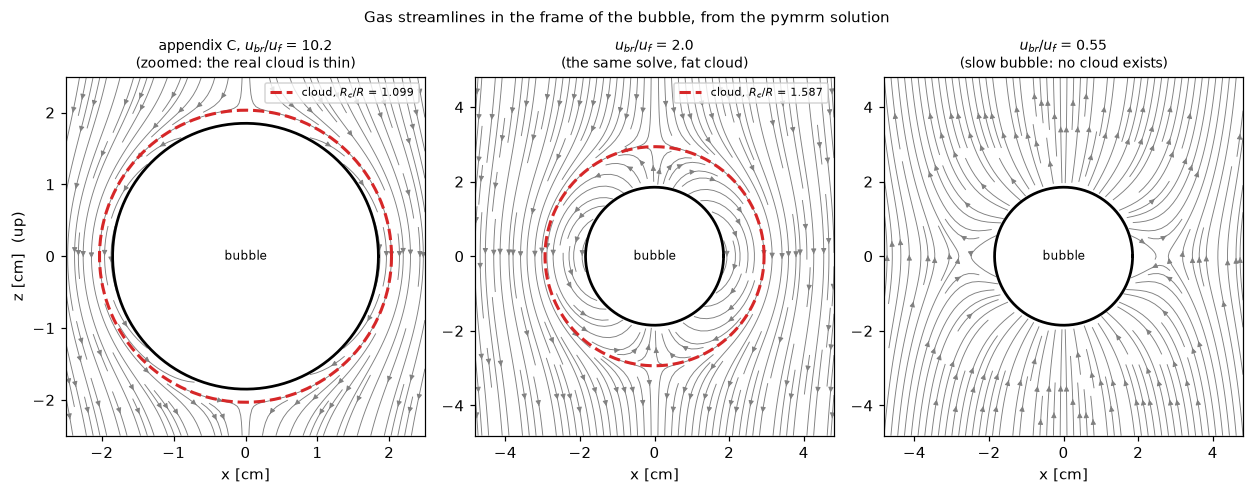

In [5]:
def velocity_field(sol, extent, n=300):
    """Cartesian gas velocity in the meridional plane, from the numerical field.

    theta runs from the upward vertical, so in (x, z)
        r_hat = (sin t, cos t),  t_hat = (cos t, -sin t)
        w_r = W(r) cos t,        w_t = -T(r) sin t
    """
    R, rmax = sol["R"], sol["x_f"][-1]
    ax1 = np.linspace(-extent * R, extent * R, n)
    X, Z = np.meshgrid(ax1, ax1)
    r = np.clip(np.hypot(X, Z), sol["x_f"][0], rmax)
    sin_t, cos_t = X / r, Z / r
    W = CubicSpline(sol["x_f"], sol["W"])(r)
    T = CubicSpline(sol["x_c"], sol["T"], extrapolate=True)(r)
    w_r, w_t = W * cos_t, -T * sin_t
    wx = w_r * sin_t + w_t * cos_t
    wz = w_r * cos_t - w_t * sin_t
    inside = np.hypot(X, Z) < R
    wx[inside] = np.nan; wz[inside] = np.nan
    return ax1, wx, wz


R_C = C["db"] / 2
moderate = davidson_bubble(R_C, C["uf"], 2.0 * C["uf"])         # a fat cloud, to see it
slow = davidson_bubble(R_C, C["uf"], 0.55 * C["uf"])            # no cloud at all

panels = [
    (solC, 1.35, f"appendix C, $u_{{br}}/u_f$ = {solC['ubr'] / solC['uf']:.1f}"
                 "\n(zoomed: the real cloud is thin)"),
    (moderate, 2.6, "$u_{br}/u_f$ = 2.0"
                    "\n(the same solve, fat cloud)"),
    (slow, 2.6, f"$u_{{br}}/u_f$ = {slow['ubr'] / slow['uf']:.2f}"
                "\n(slow bubble: no cloud exists)"),
]
fig, axes = plt.subplots(1, 3, figsize=(11.5, 4.4))
for ax, (sol, ext, ttl) in zip(axes, panels):
    R = sol["R"]
    a1, wx, wz = velocity_field(sol, ext)
    ax.streamplot(a1, a1, wx, wz, density=1.8, color="0.5", linewidth=0.6, arrowsize=0.7)
    th = np.linspace(0, 2 * np.pi, 400)
    ax.fill(R * np.cos(th), R * np.sin(th), color="white", zorder=3)
    ax.plot(R * np.cos(th), R * np.sin(th), "k-", lw=1.8, zorder=4)
    ax.annotate("bubble", (0, 0), ha="center", va="center", fontsize=8, zorder=5)
    if np.isfinite(sol["Rc"]):
        ax.plot(sol["Rc"] * np.cos(th), sol["Rc"] * np.sin(th), "C3--", lw=2.0, zorder=4,
                label=f"cloud, $R_c/R$ = {sol['Rc'] / R:.3f}")
        ax.legend(loc="upper right", fontsize=7.5)
    ax.set_aspect("equal")
    ax.set_xlim(-ext * R, ext * R); ax.set_ylim(-ext * R, ext * R)
    ax.set_title(ttl, fontsize=9); ax.set_xlabel("x [cm]"); ax.grid(False)
axes[0].set_ylabel("z [cm]  (up)")
fig.suptitle("Gas streamlines in the frame of the bubble, from the pymrm solution",
             fontsize=10)
fig.tight_layout(); plt.show()

### Where the cloud exists, and how big it is

$V_c/V_b = 3/(u_{br}/u_f - 1)$ has a pole at $u_{br} = u_f$. The cloud is
therefore not a smoothly varying property of the bed: it is unbounded on one side
of a threshold and undefined on the other. Marking the paper's own three
appendix beds on that curve is instructive.

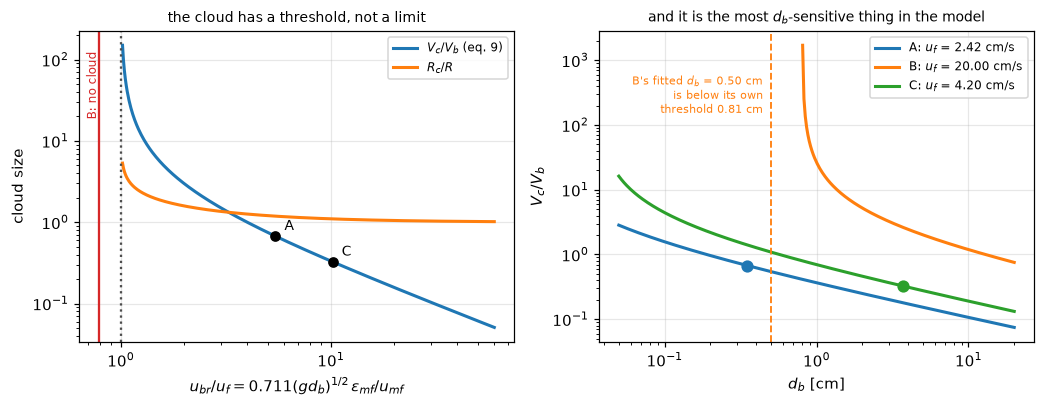

cloud size at the paper's own three appendix beds
            u_br/u_f     V_c/V_b     R_c/R
  A            5.441      0.6755    1.1877
  B            0.787   slow bubble - no cloud; eq. 9 would give V_c/V_b = -14.08
  C           10.194      0.3263    1.0987

appendix B's verdict does not rest on its stated eps_mf = 0.50.
  its printed (1-eps_f)u_b = 8.70 implies eps_mf = 0.447 (recorded on E2.1),
  which moves u_br/u_f from 0.787 to 0.704 - further below 1, not nearer it.
  a cloud would need eps_mf > 0.635 at this d_b; both values are below.


In [6]:
ratio = np.geomspace(1.02, 60, 400)
vc = 3.0 / (ratio - 1.0)

fig, ax = plt.subplots(1, 2, figsize=(9.6, 3.8))
ax[0].loglog(ratio, vc, "C0-", lw=2)
ax[0].loglog(ratio, (1 + vc) ** (1 / 3), "C1-", lw=2)
ax[0].axvline(1.0, color="0.3", ls=":")
for k, b in BEDS.items():
    x = b["ubr"] / b["uf"]
    if x > 1:
        ax[0].plot(x, 3 / (x - 1), "ko", ms=6)
        ax[0].annotate(k, (x, 3 / (x - 1)), textcoords="offset points",
                       xytext=(6, 4), fontsize=9)
    else:
        ax[0].axvline(x, color="C3", lw=1.5)
        ax[0].annotate(f"{k}: no cloud", (x, 20), rotation=90, color="C3",
                       fontsize=8, ha="right")
ax[0].set_xlabel(r"$u_{br}/u_f = 0.711(gd_b)^{1/2}\,\varepsilon_{mf}/u_{mf}$")
ax[0].set_ylabel("cloud size")
ax[0].legend(["$V_c/V_b$ (eq. 9)", "$R_c/R$"], fontsize=8)
ax[0].set_title("the cloud has a threshold, not a limit", fontsize=9)

db = np.geomspace(0.05, 20, 300)
for k, b in BEDS.items():
    ub = 0.711 * np.sqrt(G * db)
    v = np.where(ub > b["uf"], 3 * b["uf"] / (ub - b["uf"]), np.nan)
    ln, = ax[1].loglog(db, v, lw=2, label=f"{k}: $u_f$ = {b['uf']:.2f} cm/s")
    ax[1].plot(b["db"], 3 * b["uf"] / (b["ubr"] - b["uf"]) if b["ubr"] > b["uf"] else np.nan,
               "o", color=ln.get_color(), ms=7)
b = BEDS["B"]
db_thr = (b["uf"] / 0.711) ** 2 / G          # u_br(d_b) = u_f  ->  no cloud below this
ax[1].axvline(b["db"], color="C1", ls="--", lw=1.2)
ax[1].annotate(f"B's fitted $d_b$ = {b['db']:.2f} cm\nis below its own\nthreshold {db_thr:.2f} cm",
               (b["db"], 600.0), textcoords="offset points", xytext=(-5, 0),
               ha="right", va="top", fontsize=7.5, color="C1")
ax[1].set_xlabel("$d_b$ [cm]"); ax[1].set_ylabel("$V_c/V_b$")
ax[1].set_title("and it is the most $d_b$-sensitive thing in the model", fontsize=9)
ax[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

print("cloud size at the paper's own three appendix beds")
print(f"{'':10}{'u_br/u_f':>10}{'V_c/V_b':>12}{'R_c/R':>10}")
for k, b in BEDS.items():
    x = b["ubr"] / b["uf"]
    if x > 1:
        v = 3 / (x - 1)
        print(f"  {k:8}{x:10.3f}{v:12.4f}{(1 + v)**(1 / 3):10.4f}")
    else:
        print(f"  {k:8}{x:10.3f}   slow bubble - no cloud; eq. 9 would give "
              f"V_c/V_b = {3 / (x - 1):.2f}")

# Does appendix B's verdict survive a different eps_mf? The published E2.1 page
# records that appendix B's printed (1 - eps_f)u_b is inconsistent with its own
# stated eps_mf = 0.50; that printed value implies a smaller eps_mf, which makes
# u_f LARGER and the bubble relatively slower still.
b = BEDS["B"]
pr870 = printed[("B", "one_minus_ef_times_ub")]
emf_implied = 1.0 - pr870 / b["ubr"]
emf_needed = b["umf"] / b["ubr"]          # a cloud exists only above this eps_mf
print(f"\nappendix B's verdict does not rest on its stated eps_mf = {b['emf']:.2f}.")
print(f"  its printed (1-eps_f)u_b = {pr870:.2f} implies eps_mf = {emf_implied:.3f}"
      f" (recorded on E2.1),")
print(f"  which moves u_br/u_f from {b['ubr'] / b['uf']:.3f} to "
      f"{b['ubr'] * emf_implied / b['umf']:.3f} - further below 1, not nearer it.")
print(f"  a cloud would need eps_mf > {emf_needed:.3f} at this d_b; both values are below.")

## Validation

The validation ranking for this case is unusually favourable: **routes 1 and 2
are both available and no figure is needed**. Nothing here is digitised.

**Route 1 — worked examples with printed intermediates.** Kunii & Levenspiel
print three appendices, and every one of them evaluates one of these
single-bubble quantities with the arithmetic shown and the answer stated.
Appendix C's $\gamma_c$ line is a fully substituted evaluation of equation 9.

**Say plainly what route 1 is and is not.** All eight of the printed values
recomputed below are **already published on `E2.1`, to every digit**, from the
same single transcription — this page loads that CSV cross-page rather than
copying it. Both route-1 headline figures, the 1.06 % worst case and the 0.43 %
on $K_{bc}$/$H_{bc}$, are `E2.1`'s numbers reached here by a second route. They
are a check that the transcription was read the same way twice, **not**
independent corroboration, and nobody should count them twice. What is genuinely
new on this page is route 2: the `4.5` rebuilt from a flow field that never sees
it, and the threshold result below.

**Route 2 — an internal identity the model must satisfy.** The through-flow
computed from the numerical field is used to *rebuild* the `4.5` that Kunii and
Levenspiel print in equations 10 and 11. That coefficient was never used as an
input here; it comes out of $-f'(R) = 3u_f$ and the surface integral, so it is an
independent witness to the reading of the equation and to the derivation. Check 9
sabotages the operator seven ways and shows that this is the number that moves —
every injected defect shifts it, the mildest by a third and the worst by a factor
of three — while two of the other reported numbers sit unmoved through defects
that ruin the field completely.

Then the numerical machinery is checked against the closed form derived on this
page — which tests the discretisation, not the physics — and the cloud radius is
obtained a **second way**, by integrating gas trajectories through the numerical
velocity field and bisecting on the release radius until a streamline stops
returning to the bubble. That second route agrees at machine precision, and it
should: the separatrix *is* the surface $W = 0$. What it independently confirms is
the topology claim — that the root of $W$ really is where gas stops returning —
not a second estimate carrying its own error.

**Two of the reported numbers are weaker than they look, and check 9 measures how
much weaker.** The discrete integral identity is an *algebraic* identity: `lhs −
rhs` is the volume-weighted sum of the discrete residuals, and it telescopes for
any consistent (`construct_div`, cell-volume, $\nu$) triple with any boundary
data. It detects a **mismatch** between the $\nu$ inside `construct_div` and the
one in the sink term, and nothing else — not a wrong-but-consistent $\nu$, not a
mis-signed boundary condition. And $R_c/R$ is blind to a common-mode far-field
error, because flipping the sign of the outer `d` rescales *both* potentials and
leaves the root of $W = g' - f'$ where it was. Neither is a defect in the model;
both are stated here so that an agent copying this `S3` skeleton knows which line
of output to watch, and it is the through-flow `4.5`, not the conservation
line.

In [7]:
# 1. The numerical field against the closed form it must reproduce, and the order.
print("1. Grid convergence against the closed form  f = -u_f (r - R^3/r^2),")
print("   g = -u_br (r + R^3/2r^2),  R_c/R = [(u_br + 2u_f)/(u_br - u_f)]^(1/3)\n")
R, uf, ubr = C["db"] / 2, C["uf"], C["ubr"]
Rc_exact = R * ((ubr + 2 * uf) / (ubr - uf)) ** (1 / 3)
print(f"   {'n':>6}{'max|f - f_exact|/u_f R':>26}{'|q err|':>12}{'|R_c err|/R':>14}{'order':>8}")
err_f, err_q, err_r = [], [], []
for n in (100, 200, 400, 800, 1600):
    s = davidson_bubble(R, uf, ubr, n=n)
    err_f.append(np.max(np.abs(s["f"] + uf * (s["x_c"] - R**3 / s["x_c"]**2))) / (uf * R))
    err_q.append(abs(-s["df"][0] - 3 * uf) / (3 * uf))
    err_r.append(abs(s["Rc"] - Rc_exact) / R)
    order = "" if len(err_f) < 2 else f"{np.log2(err_f[-2] / err_f[-1]):8.2f}"
    print(f"   {n:6d}{err_f[-1]:26.3e}{err_q[-1]:12.3e}{err_r[-1]:14.3e}{order}")
results["grid_order_observed"] = float(np.log2(err_f[-2] / err_f[-1]))
results["f_field_rel_error_n1600"] = float(err_f[-1])
results["Rc_rel_error_n1600"] = float(err_r[-1])
print(f"\n   observed order {results['grid_order_observed']:.3f}; the discretisation is")
print("   second order and the far-field Robin condition contributes nothing.")

1. Grid convergence against the closed form  f = -u_f (r - R^3/r^2),
   g = -u_br (r + R^3/2r^2),  R_c/R = [(u_br + 2u_f)/(u_br - u_f)]^(1/3)

        n    max|f - f_exact|/u_f R     |q err|   |R_c err|/R   order
      100                 5.087e-04   2.986e-04     1.999e-05
      200                 1.272e-04   7.264e-05     4.800e-06    2.00
      400                 3.182e-05   1.790e-05     1.175e-06    2.00
      800                 7.955e-06   4.444e-06     2.906e-07    2.00
     1600                 1.989e-06   1.107e-06     7.229e-08    2.00

   observed order 2.000; the discretisation is
   second order and the far-field Robin condition contributes nothing.


In [8]:
# 2. The cloud radius a second way: integrate gas streamlines, bisect on release radius.
sol = solC
Sdf, Sdg = CubicSpline(sol["x_f"], sol["df"]), CubicSpline(sol["x_f"], sol["dg"])
Sf = CubicSpline(sol["x_c"], sol["f"], extrapolate=True)
Sg = CubicSpline(sol["x_c"], sol["g"], extrapolate=True)


def trajectory_returns(r0, th0=0.1, tmax=60.0):
    """Release a gas element just above the bubble; does it come back to it?"""
    def rhs(t, y):
        r, th = y
        w_r = (Sdg(r) - Sdf(r)) * np.cos(th)          # w_r = W(r) cos(theta)
        w_t = -((Sg(r) - Sf(r)) / r) * np.sin(th)     # w_t = -T(r) sin(theta)
        return [w_r, w_t / r]
    hit = lambda t, y: y[0] - sol["R"];        hit.terminal = True;  hit.direction = -1
    gone = lambda t, y: y[0] - 4 * sol["Rc"];  gone.terminal = True; gone.direction = 1
    s = solve_ivp(rhs, (0, tmax), [r0, th0], events=[hit, gone],
                  rtol=1e-10, atol=1e-12, max_step=0.05)
    return len(s.t_events[0]) > 0


lo, hi = sol["R"] * 1.001, sol["Rc"] * 3
for _ in range(45):
    mid = 0.5 * (lo + hi)
    lo, hi = (mid, hi) if trajectory_returns(mid) else (lo, mid)
Rc_traj = 0.5 * (lo + hi)

print("2. Two independent routes to the cloud radius")
print(f"   root of the radial amplitude W(r)     R_c = {sol['Rc']:.9f} cm")
print(f"   bisection on streamline fate          R_c = {Rc_traj:.9f} cm")
print(f"   closed form [(u_br+2u_f)/(u_br-u_f)]^(1/3)  = {Rc_exact:.9f} cm")
results["Rc_two_routes_rel"] = float(abs(Rc_traj - sol["Rc"]) / sol["Rc"])
print(f"\n   The two agree to {results['Rc_two_routes_rel']:.2e}. That is machine")
print("   precision, and it should be: the separatrix IS the surface W = 0, so the")
print("   trajectory route is not a second estimate with independent error. What it")
print("   tests is the TOPOLOGY claim - that this radius is where gas stops")
print("   returning to the bubble - which the stream-function derivation asserts")
print("   and the ODE integration confirms without using it.")

2. Two independent routes to the cloud radius
   root of the radial amplitude W(r)     R_c = 2.032606036 cm
   bisection on streamline fate          R_c = 2.032606036 cm
   closed form [(u_br+2u_f)/(u_br-u_f)]^(1/3)  = 2.032606170 cm

   The two agree to 1.22e-14. That is machine
   precision, and it should be: the separatrix IS the surface W = 0, so the
   trajectory route is not a second estimate with independent error. What it
   tests is the TOPOLOGY claim - that this radius is where gas stops
   returning to the bubble - which the stream-function derivation asserts
   and the ODE integration confirms without using it.


In [9]:
# 3. The through-flow rebuilds the 4.5 that opens equations 10 and 11.
print("3. Through-flow per unit bubble volume, from the numerical field\n")
print("   q = eps_mf * (-f'(R)) * pi R^2  (outflow over the upper hemisphere)")
print("   q / V_b = q / (4/3 pi R^3)\n")
print(f"   {'bed':>5}{'q/V_b [1/s]':>14}{'(q/V_b) d_b/u_mf':>20}{'printed':>10}{'dev':>10}")
worst_45 = 0.0
for k, b in BEDS.items():
    s = davidson_bubble(b["db"] / 2, b["uf"], b["ubr"], n=1600)
    q = b["emf"] * s["mdot_over_eps"]                    # cm^3/s per bubble
    q_over_Vb = q / (4 / 3 * np.pi * s["R"] ** 3)
    coeff = q_over_Vb * b["db"] / b["umf"]
    worst_45 = max(worst_45, abs(coeff - 4.5) / 4.5)
    b["q_over_Vb"] = q_over_Vb
    print(f"   {k:>5}{q_over_Vb:14.5f}{coeff:20.6f}{4.5:10.1f}{abs(coeff - 4.5) / 4.5:10.2e}")
results["throughflow_coefficient_rel"] = float(worst_45)
print(f"\n   The coefficient 4.5 was not an input. It is 3 u_mf pi R^2 / V_b, and it")
print(f"   comes out of the solve to {worst_45:.1e} relative.")
print("   The three beds agree to every printed digit, and that is not three")
print("   confirmations: eps_mf, u_mf and d_b all cancel out of the expression, so")
print("   the coefficient is a PURE NUMBER - which is itself the point. The grid is")
print("   geometric in r/R, so even the discretisation error is scale-invariant.")
print(f"   Read {worst_45:.1e} as the discretisation error, not as the strength of")
print("   the agreement: the content of this check is binary, 4.5 against anything")
print("   else, and check 9 below measures how far 'anything else' actually is.")
print("   Note it does NOT require a fast bubble: u_br never enters the gas potential.")

3. Through-flow per unit bubble volume, from the numerical field

   q = eps_mf * (-f'(R)) * pi R^2  (outflow over the upper hemisphere)
   q / V_b = q / (4/3 pi R^3)

     bed   q/V_b [1/s]    (q/V_b) d_b/u_mf   printed       dev
       A      15.55713            4.499995       4.5  1.11e-06
       B      89.99990            4.499995       4.5  1.11e-06
       C       2.55405            4.499995       4.5  1.11e-06

   The coefficient 4.5 was not an input. It is 3 u_mf pi R^2 / V_b, and it
   comes out of the solve to 1.1e-06 relative.
   The three beds agree to every printed digit, and that is not three
   confirmations: eps_mf, u_mf and d_b all cancel out of the expression, so
   the coefficient is a PURE NUMBER - which is itself the point. The grid is
   geometric in r/R, so even the discretisation error is scale-invariant.
   Read 1.1e-06 as the discretisation error, not as the strength of
   the agreement: the content of this check is binary, 4.5 against anything
   else, and che

In [10]:
# 4. Reassemble K_bc and H_bc using the derived through-flow plus the printed
#    5.85 diffusive terms, and compare with the appendices' printed totals.
print("4. K_bc and H_bc rebuilt with the derived through-flow\n")
A, B = BEDS["A"], BEDS["B"]
Kbc_A = A["q_over_Vb"] + 5.85 * (A["D"] ** 0.5 * G ** 0.25 / A["db"] ** 1.25)     # eq. 10
Kbc_C = C["q_over_Vb"] + 5.85 * (C["D"] ** 0.5 * G ** 0.25 / C["db"] ** 1.25)     # eq. 10
Hbc_B = (B["q_over_Vb"] * B["rho_g"] * B["Cpg"]
         + 5.85 * (B["kg"] * B["rho_g"] * B["Cpg"]) ** 0.5 * G ** 0.25 / B["db"] ** 1.25)  # eq. 11

rows = [("K_bc, appendix A [1/s]", Kbc_A, printed[("A", "K_bc")]),
        ("K_bc, appendix C [1/s]", Kbc_C, printed[("C", "K_bc")]),
        ("H_bc, appendix B [cal/cc s C]", Hbc_B, printed[("B", "H_bc")])]
print(f"   {'quantity':>32}{'computed':>14}{'printed':>12}{'dev':>9}")
for name, got, want in rows:
    print(f"   {name:>32}{got:14.5g}{want:12.5g}{100 * abs(got - want) / want:8.2f} %")
results["Kbc_Hbc_worst_pct"] = float(max(100 * abs(g_ - w) / w for _, g_, w in rows))

4. K_bc and H_bc rebuilt with the derived through-flow

                           quantity      computed     printed      dev
             K_bc, appendix A [1/s]        46.555        46.5    0.12 %
             K_bc, appendix C [1/s]        5.4349        5.44    0.09 %
      H_bc, appendix B [cal/cc s C]      0.035845       0.036    0.43 %


In [11]:
# 5. The Davidson members of the three printed appendices.
print("5. Printed appendix values, recomputed\n")
gc_num = (1 - C["emf"]) * ((solC["Rc"] / solC["R"]) ** 3 - 1 + C["alpha"])   # eq. 17
gc_eq9 = (1 - C["emf"]) * (3 * C["uf"] / (C["ubr"] - C["uf"]) + C["alpha"])  # eq. 17 verbatim
ub_C = C["u0"] - C["umf"] + C["ubr"]                                         # eq. 3

rows = [
    ("u_b - u_0, appendix A [cm/s]", A["ubr"] - A["umf"], printed[("A", "ub_minus_u0")]),
    ("u_b - u_0, appendix B [cm/s]", B["ubr"] - B["umf"], printed[("B", "ub_minus_u0")]),
    ("u_br, appendix C [cm/s]", C["ubr"], printed[("C", "u_br")]),
    ("u_b, appendix C [cm/s]", ub_C, printed[("C", "u_b")]),
    ("gamma_c, appendix C  (eq. 9 as printed)", gc_eq9, printed[("C", "gamma_c")]),
    ("gamma_c, appendix C  (cloud from pymrm)", gc_num, printed[("C", "gamma_c")]),
]
print(f"   {'quantity':>42}{'computed':>12}{'printed':>10}{'dev':>9}")
for name, got, want in rows:
    print(f"   {name:>42}{got:12.5g}{want:10.5g}{100 * abs(got - want) / want:8.2f} %")
results["appendix_worst_pct"] = float(max(100 * abs(g_ - w) / w for _, g_, w in rows))
results["gamma_c_from_pymrm_cloud_pct"] = float(100 * abs(gc_num - printed[("C", "gamma_c")])
                                                / printed[("C", "gamma_c")])
print(f"\n   The last two lines are the point. Equation 9 never enters the solve -")
print("   only the two boundary conditions and u_f, u_br do - so substituting the")
print("   cloud computed here for the printed formula is a real test of the")
print(f"   derivation. It moves gamma_c by {100 * abs(gc_num - gc_eq9) / gc_eq9:.1e} %.")

5. Printed appendix values, recomputed

                                     quantity    computed   printed      dev
                 u_b - u_0, appendix A [cm/s]      11.958        12    0.35 %
                 u_b - u_0, appendix B [cm/s]      5.7387       5.8    1.06 %
                      u_br, appendix C [cm/s]      42.814      42.8    0.03 %
                       u_b, appendix C [cm/s]      53.914      53.9    0.03 %
      gamma_c, appendix C  (eq. 9 as printed)     0.39815       0.4    0.46 %
      gamma_c, appendix C  (cloud from pymrm)     0.39815       0.4    0.46 %

   The last two lines are the point. Equation 9 never enters the solve -
   only the two boundary conditions and u_f, u_br do - so substituting the
   cloud computed here for the printed formula is a real test of the
   derivation. It moves gamma_c by 3.3e-05 %.


In [12]:
# 6. The limits the model must have.
print("6. Limits\n")
lim = []
for x in (1.001, 1.01, 1.1, 2.0, 10.0, 100.0, 1000.0):
    s = davidson_bubble(1.0, 1.0, x, n=1600)
    lim.append((x, s["Rc"], 3 / (x - 1)))
print(f"   {'u_br/u_f':>10}{'R_c/R numeric':>16}{'(1+3/(x-1))^(1/3)':>20}")
for x, rc, v in lim:
    print(f"   {x:10.3f}{rc:16.6f}{(1 + v) ** (1 / 3):20.6f}")
results["limit_worst_rel"] = float(max(abs(rc - (1 + v) ** (1 / 3)) / rc for _, rc, v in lim))

slow_test = davidson_bubble(1.0, 1.0, 0.9, n=1600)
print(f"\n   u_br/u_f = 0.90 : root finder returns {slow_test['Rc']} - no dividing")
print("   streamline exists, which is the correct answer, not a failure.")
print(f"   u_br/u_f -> large : R_c/R -> 1 ({lim[-1][1]:.6f} at 1000), the cloud")
print("   collapses onto the bubble surface.")
print(f"   u_br/u_f -> 1+    : R_c/R -> infinity ({lim[0][1]:.3f} at 1.001).")
print(f"\n   worst deviation from the closed form over seven decades: "
      f"{results['limit_worst_rel']:.2e}")

6. Limits

     u_br/u_f   R_c/R numeric   (1+3/(x-1))^(1/3)
        1.001       14.424090           14.424098
        1.010        6.701756            6.701759
        1.100        3.141380            3.141381
        2.000        1.587401            1.587401
       10.000        1.100642            1.100642
      100.000        1.010001            1.010001
     1000.000        1.001000            1.001000

   u_br/u_f = 0.90 : root finder returns nan - no dividing
   streamline exists, which is the correct answer, not a failure.
   u_br/u_f -> large : R_c/R -> 1 (1.001000 at 1000), the cloud
   collapses onto the bubble surface.
   u_br/u_f -> 1+    : R_c/R -> infinity (14.424 at 1.001).

   worst deviation from the closed form over seven decades: 5.32e-07


In [13]:
# 7. The discrete integral identity - and it is an IDENTITY, not a test.
#    Integrating the radial equation once over [R, r_out] gives
#        int_R^r_out  nu h / r^2 * r^nu dr  =  [ r^nu dh/dr ]_R^r_out
#    Evaluated on the DISCRETE solution, lhs - rhs is the volume-weighted sum of
#    the discrete residuals, which telescopes for ANY consistent
#    (construct_div, cell-volume, nu) triple and ANY boundary data.  So it is
#    NOT a check on the physics: it cannot see a wrong-but-consistent nu and it
#    cannot see a mis-signed boundary condition.  What it CAN see is a MISMATCH
#    between the geometry index inside construct_div and the one in the sink
#    term.  Check 9 measures exactly that, rather than asserting it.
def integral_identity(sol, h, dh):
    x_f, x_c, nu = sol["x_f"], sol["x_c"], sol["nu"]
    vol = (x_f[1:] ** (nu + 1) - x_f[:-1] ** (nu + 1)) / (nu + 1)   # cell volumes / (area const)
    lhs = np.sum(vol * nu * h / x_c ** 2)
    rhs = x_f[-1] ** nu * dh[-1] - x_f[0] ** nu * dh[0]
    return abs(lhs - rhs) / abs(rhs)


s = solC
closure = max(integral_identity(s, s["f"], s["df"]), integral_identity(s, s["g"], s["dg"]))
print(f"7. Discrete integral identity, both potentials: {closure:.2e} relative")
print("   This is an ALGEBRAIC identity - the volume-weighted sum of the discrete")
print("   residuals - and it closes for any consistent operator with any boundary")
print("   data. It is reported for what it is, and it is NOT evidence that the")
print("   field is right; check 9 shows which defects it sees and which it does not.")

7. Discrete integral identity, both potentials: 1.96e-12 relative
   This is an ALGEBRAIC identity - the volume-weighted sum of the discrete
   residuals - and it closes for any consistent operator with any boundary
   data. It is reported for what it is, and it is NOT evidence that the
   field is right; check 9 shows which defects it sees and which it does not.


In [14]:
# 8. The two-dimensional bubble: the same operator with nu = 1.
sol2d = davidson_bubble(C["db"] / 2, C["uf"], C["ubr"], n=1600, nu=1)
Rc2_exact = (C["db"] / 2) * ((C["ubr"] + C["uf"]) / (C["ubr"] - C["uf"])) ** 0.5
print("8. The same operator with nu = 1 is the two-dimensional (slab-bed) bubble:")
print(f"   R_c/R = {sol2d['Rc'] / sol2d['R']:.6f} against the 3-D {solC['Rc'] / solC['R']:.6f}")
print(f"   closed form [(u_br+u_f)/(u_br-u_f)]^(1/2) = {Rc2_exact / sol2d['R']:.6f}, "
      f"deviation {abs(sol2d['Rc'] - Rc2_exact) / Rc2_exact:.2e}")
results["cloud_2d_rel_error"] = float(abs(sol2d["Rc"] - Rc2_exact) / Rc2_exact)
print(f"   through-flow per unit bubble volume: "
      f"{C['emf'] * sol2d['mdot_over_eps'] / (np.pi * sol2d['R']**2):.6f} 1/s "
      f"= {8 * C['umf'] / (np.pi * C['db']):.6f} = 8 u_mf/(pi d_b) = 2.55 u_mf/d_b,")
print(f"   against 4.5 u_mf/d_b in three dimensions.")

8. The same operator with nu = 1 is the two-dimensional (slab-bed) bubble:
   R_c/R = 1.103421 against the 3-D 1.098706
   closed form [(u_br+u_f)/(u_br-u_f)]^(1/2) = 1.103421, deviation 3.90e-08
   through-flow per unit bubble volume: 1.445298 1/s = 1.445299 = 8 u_mf/(pi d_b) = 2.55 u_mf/d_b,
   against 4.5 u_mf/d_b in three dimensions.


In [15]:
# 9. Break it on purpose, and measure what each reported number does.
#    Every row re-solves appendix C's bubble with exactly ONE thing sabotaged,
#    through the no-op `defect` hooks in solve_mode. Nothing here is retyped:
#    the table is computed when this cell runs.
DEFECTS = [
    ("(baseline, nothing broken)",          dict(),                  2),
    ("nu = 1 everywhere (2-D operator)",    dict(),                  1),
    ("nu = 1 in construct_div only",        dict(nu_div=1),          2),
    ("nu = 1 in the sink term only",        dict(sink_coeff=1),      2),
    ("sink coefficient 6 (l = 2 harmonic)", dict(sink_coeff=6),      2),
    ("far-field amplitude nu, not nu+1",    dict(far_factor=2.0),    2),
    ("outer BC a = -1 (normal flipped)",    dict(outer_a=-1.0),      2),
    ("outer BC d sign flipped",             dict(outer_d_sign=-1.0), 2),
]
print("9. Injected defects: which numbers move, and which do not\n")
print(f"   {'injected defect':<36}{'4.5 ->':>10}{'field err':>11}{'R_c/R err':>11}{'identity':>11}")
mismatch, blind = [], []
for name, dfc, nu_i in DEFECTS:
    sd = davidson_bubble(R, uf, ubr, n=1600, nu=nu_i, defect=dfc)
    coeff = (C["emf"] * sd["mdot_over_eps"] / (4 / 3 * np.pi * R**3)) * C["db"] / C["umf"]
    ferr = np.max(np.abs(sd["f"] + uf * (sd["x_c"] - R**3 / sd["x_c"]**2))) / (uf * R)
    rerr = abs(sd["Rc"] - Rc_exact) / R if np.isfinite(sd["Rc"]) else np.nan
    idy = max(integral_identity(sd, sd["f"], sd["df"]),
              integral_identity(sd, sd["g"], sd["dg"]))
    print(f"   {name:<36}{coeff:10.3f}{ferr:11.1e}{rerr:11.1e}{idy:11.1e}")
    if name != "(baseline, nothing broken)":
        # The identity's one genuine power is a MISMATCH between the geometry
        # index inside construct_div and the coefficient of the sink term.
        # Classify each defect by that structural property, not by its outcome.
        bucket = (mismatch if dfc.get("nu_div", nu_i) != dfc.get("sink_coeff", nu_i)
                  else blind)
        bucket.append((name, coeff, ferr, rerr, idy))

allb = mismatch + blind
results["defect_min_throughflow_shift"] = float(min(abs(r[1] - 4.5) / 4.5 for r in allb))
results["defect_identity_worst_blind"] = float(max(r[4] for r in blind))
results["defect_identity_mismatch_detected"] = float(min(r[4] for r in mismatch))
print(f"\n   Every one of the {len(allb)} defects moves the through-flow coefficient, the")
print(f"   smallest shift being {100 * results['defect_min_throughflow_shift']:.0f} % and the largest a factor of "
      f"{max(abs(r[1]) for r in allb) / 4.5:.1f}.")
print("   That is the guard on this page, and it is the only one of these numbers")
print("   that catches every defect.")
print(f"   The identity catches exactly the {len(mismatch)} nu MISMATCHES, and does so loudly")
print(f"   ({results['defect_identity_mismatch_detected']:.1e} at its weakest). On the other {len(blind)} it stays at "
      f"{results['defect_identity_worst_blind']:.1e} - round-off -")
print("   including the mis-signed outer boundary condition that destroys the")
print("   field. R_c/R is blind to that one too: both potentials rescale together,")
print("   so the root of W = g' - f' does not move. Only the through-flow and the")
print("   field error see it.")

9. Injected defects: which numbers move, and which do not

   injected defect                         4.5 ->  field err  R_c/R err   identity
   (baseline, nothing broken)               4.500    2.0e-06    7.2e-08    2.0e-12
   nu = 1 everywhere (2-D operator)         1.032    2.5e-01    4.7e-03    4.7e-13
   nu = 1 in construct_div only             1.078    3.5e+00    2.7e-02    4.2e-01
   nu = 1 in the sink term only            12.071    4.9e+00    6.1e-02    1.0e+00
   sink coefficient 6 (l = 2 harmonic)      0.281    6.7e+00    4.9e-02    6.7e-01
   far-field amplitude nu, not nu+1         3.000    6.7e+00    7.2e-08    2.0e-12
   outer BC a = -1 (normal flipped)        13.507    4.0e+01    7.5e-05    2.0e-12
   outer BC d sign flipped                 -4.500    4.0e+01    7.2e-08    2.0e-12

   Every one of the 7 defects moves the through-flow coefficient, the
   smallest shift being 33 % and the largest a factor of 3.0.
   That is the guard on this page, and it is the only one of 

In [16]:
report_agreement("E1.2", results)

Agreement metrics for E1.2:
  grid_order_observed               = 2
  f_field_rel_error_n1600           = 1.9888e-06
  Rc_rel_error_n1600                = 7.2285e-08
  Rc_two_routes_rel                 = 1.2235e-14
  throughflow_coefficient_rel       = 1.1068e-06
  Kbc_Hbc_worst_pct                 = 0.43047
  appendix_worst_pct                = 1.0577
  gamma_c_from_pymrm_cloud_pct      = 0.46148
  limit_worst_rel                   = 5.3231e-07
  cloud_2d_rel_error                = 3.8987e-08
  defect_min_throughflow_shift      = 0.33333
  defect_identity_worst_blind       = 1.9962e-12
  defect_identity_mismatch_detected = 0.41567


{'page': 'E1.2',
 'metrics': {'grid_order_observed': 1.9999511757242392,
  'f_field_rel_error_n1600': 1.988754958855863e-06,
  'Rc_rel_error_n1600': 7.22850850647743e-08,
  'Rc_two_routes_rel': 1.223502996060572e-14,
  'throughflow_coefficient_rel': 1.1068242020684238e-06,
  'Kbc_Hbc_worst_pct': 0.43046588877058906,
  'appendix_worst_pct': 1.0576566438272068,
  'gamma_c_from_pymrm_cloud_pct': 0.4614776656693409,
  'limit_worst_rel': 5.32314603588234e-07,
  'cloud_2d_rel_error': 3.898713179039532e-08,
  'defect_min_throughflow_shift': 0.3333340712161339,
  'defect_identity_worst_blind': 1.9962175461539053e-12,
  'defect_identity_mismatch_detected': 0.41566864702081485}}

## What pymrm adds

**Nothing to the closed form.** The classical solution is exact and the algebra is
short. The page says so rather than manufacturing an improvement.

**One flow field, read twice.** In the reactor literature the cloud volume and
the interchange coefficient are two *consecutive* equations, 9 and 10 — and
nothing in the paper connects them. Neither is derived; both are stated, with
different-looking constants (`3` in equation 9, `4.5` in equations 10 and 11) and
a reference to a companion paper. Solving the field once and reading both off it
shows they are the same object: $-f'(R) = 3u_f$ gives the through-flow, and the
*sum* of that gas flux
with the solids potential-flow gives the dividing streamline. The `4.5` is
recovered without ever being used as an input, which is the strongest available
check that equation 10 was read correctly off the page. The 1e-6 printed beside
it is discretisation error; the check's real content is binary, and check 9
measures how loudly it fails — every one of seven injected operator defects moves
that coefficient, the mildest by a third and the worst by a factor of three.

**A limit that is a threshold, not a limit.** $V_c/V_b = 3/(u_{br}/u_f - 1)$ has
a pole. Below it there is no cloud at all — the streamline integration finds no
closed orbit, which is the correct answer rather than a numerical failure — and
equation 9 returns a negative number. Applying that test to the paper's own three
appendix beds puts **appendix B on the wrong side of it**: with its printed
$d_b$ = 0.50 cm, $u_{mf}$ = 10 cm/s and $\varepsilon_{mf}$ = 0.50,
$u_{br}/u_f$ = 0.787 and equation 9 would give $V_c/V_b$ = −14.1. Nothing in the
paper is wrong — appendix B is a heat-transfer example that needs $\gamma_b$ and
$H_{bc}$ and never evaluates equation 9 — but a reader who carries equation 9
into a bed like that gets a nonsense number with no *quantitative* warning: the
paper says equation 9 is for "beds with fast rising bubbles" and never says how
fast is fast. The bubble would have to exceed $d_b$ = 0.81 cm for a cloud to
exist there.

That verdict does not depend on the one number in appendix B that is in doubt.
The published `E2.1` page records that appendix B's printed
$(1-\varepsilon_f)u_b$ = 8.70 is inconsistent with its own stated
$\varepsilon_{mf}$ = 0.50, and implies $\varepsilon_{mf}$ ≈ 0.447 instead. A
*smaller* $\varepsilon_{mf}$ makes $u_f = u_{mf}/\varepsilon_{mf}$ larger, so it
moves $u_{br}/u_f$ from 0.787 down to 0.704 — further from the threshold, not
nearer. Nothing below $\varepsilon_{mf}$ = 0.635 gives that bed a cloud.

**The through-flow, unlike the cloud, has no such threshold.** $u_{br}$ never
enters the gas potential; the bubble's speed affects where the gas *goes*, not
how much crosses the surface. So the `4.5` term in equations 10 and 11 is valid
on both sides of the threshold, and the `3` in equation 9 is not. The two
constants are usually quoted together as though they had the same standing.
One honest qualification: what is speed-independent is the *volumetric*
through-flow $q = 3u_{mf}\pi R^2$. Whether $q/V_b$ still deserves the name
"bubble-to-cloud interchange" below the threshold is an interpretive step, since
the two-phase series bubble → cloud → emulsion has lost its middle term there.
The flux is the same; the label it is given is not this page's to settle.

**The two-dimensional bubble, for free.** Changing one argument, `nu=1` instead
of `nu=2`, turns the same operator into the slab-bed problem and gives
$R_c/R = [(u_{br}+u_f)/(u_{br}-u_f)]^{1/2}$ — an exponent of $1/2$ instead of
$1/3$, so a systematically **larger** cloud at the same velocity ratio (1.103
against 1.099 for appendix C's bed, and the gap widens fast as $u_{br}\to u_f$).
That matters because photographs of bubbles and clouds mostly come from
two-dimensional beds while the correlations they calibrate are three-dimensional.
This result is derived here; Kunii & Levenspiel print only the three-dimensional
form.

**And the honest negative.** This page cannot say whether any of it is *true*.
Nothing on it is compared with a measurement — the source contains none for a
single bubble — so every number is either the authors' own arithmetic or this
page's own derivation. Tier 6.

## Reuse

```python
from pymrm import construct_grad, construct_div, construct_coefficient_matrix

sol = davidson_bubble(R=1.85, uf=4.2, ubr=42.81, n=1600)     # 3-D bubble
sol["Rc"] / sol["R"]                                          # cloud radius ratio
sol["mdot_over_eps"]                                          # through-flow / eps_mf
davidson_bubble(R=1.85, uf=4.2, ubr=42.81, nu=1)              # 2-D (slab-bed) bubble
```

**What transfers.** `solve_mode` is not really about bubbles. It is the radial
factor of *any* $\ell = 1$ spherical or cylindrical harmonic with a mixed set of
boundary conditions, which is the shape of every "uniform far field meets a
sphere" problem: flow past a drop, a conducting sphere in a uniform electric
field, a spherical inclusion in a temperature gradient, Stokes-flow effective
conductivity. The two boundary conditions used here — potential fixed on the
sphere, and normal derivative zero on the sphere — are the two limiting cases
those problems interpolate between.

The **exact far-field Robin condition** $h' + (\nu/r)h = (\nu+1)A$ is the
reusable trick. Any time a solution is a sum of a growing and a decaying
separable mode, there is a combination of value and derivative that annihilates
the decaying one, and imposing it lets a finite domain carry an infinite one with
no truncation error. Grid convergence then measures the discretisation alone,
which is what makes the second-order result above meaningful.

**What does not transfer.** $d_b$ is not a measured bubble diameter; in the
reactor model it is a fitted effective size, and `E2.1` says so at length. The
wake fraction $\alpha$ in equation 17 is empirical and is *not* part of this
theory — potential flow past a sphere has no wake. And the spherical bubble is a
convenience: real bubbles are spherical caps.

**Where else this structure appears.** As a 1D steady BVP with `construct_grad` +
`construct_div` and a geometry index it is the same `S3` skeleton as `B1.1`
(Thiele modulus), `B1.6` (Prater relation) and `J1.5` (LDF), differing only in
what multiplies the unknown.
As *physics* the continuation is `E2.1`, which takes $u_{br}$, $V_c/V_b$ and
$K_{bc}$ as inputs and builds the bubbling-bed reactor model on them; `E1.1`
(two-phase theory) is the earlier picture this refined, and it is catalogued but
has no page.

**And if you copy this skeleton, watch the right line.** The number that catches a
broken operator here is the through-flow `4.5`, not the conservation line: check 9
shows the discrete integral identity sitting at round-off while a mis-signed outer
boundary condition ruins the field by seven orders of magnitude. Boundary-sign errors
are the most common pymrm mistake, and a closing conservation check is not
evidence against one.